# Многоцелевая модель для NER + event-CLS

Данный проект направлен на решение двух аналитических проблем:
- Извлечение сущностей из новостных текстов (NER)
- Определяет набор характеристик в тексте (CLS)

Это позволяет автоматически помечать важные факты в новостях (персоны, организации, даты) и формировать теги и инцидентные фильтры для быстрого поиска и аналитики. Предложенное решение позволило объединить две эти задачи в едином пайплайне и решать обе задачи используя единую нейросеть.

In [ ]:
import os 
import time
from functools import wraps

import json
from collections import Counter
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

import random
import numpy as np

import re

from datasets import Dataset, DatasetDict
from transformers import AutoTokenizer, AutoModel
from transformers import DataCollatorForTokenClassification

import torch
from torch import nn
from torch import optim
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import LinearLR, CosineAnnealingLR, SequentialLR

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score, confusion_matrix, classification_report

W0624 21:04:37.342000 4972 site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


In [2]:
PATH_TRAIN = 'data/train.jsonl'
PATH_DEV = 'data/dev.jsonl'
PATH_TEST = 'data/test.jsonl'
PATH_REL = 'data/rel_types.jsonl'

MODEL_NAME = 'ai-forever/ruBert-base'
SEED = 357

SAVE_MODEL_PATH = 'models/best_model.pth'

## EDA

In [3]:
train_data = []
with open(PATH_TRAIN, 'r', encoding='utf-8') as file:
    for line in file:
        train_data.append(json.loads(line.strip()))

Посмотрим на ключи в json

In [4]:
train_data[0].keys()

dict_keys(['id', 'text', 'entities', 'relations', 'links'])

Выведем  первые 200 символов текста для первого и последнего документа

In [5]:
print(train_data[0]['text'][:200])
print('\n')
print('-' * 50)
print(train_data[-1]['text'][:200])

Пулеметы, автоматы и снайперские винтовки изъяты в арендуемом американцами доме в Бишкеке

05/08/2008 10:35

БИШКЕК, 5 августа /Новости-Грузия/. Правоохранительные органы Киргизии обнаружили в доме, а


--------------------------------------------------
Умер Имре Кертес
Имре Кертес
30 марта 2016 года в Будапеште, Венгрия, после долгой борьбы с болезнью скончался венгерский 86-летний писатель Имре Кертес.

В 15 лет Кертес попал в Освенцим, после чего 


Судя по структуре мы имеем новостные тексты либо информации о каких-то событиях из википедии.

Посмотрим какие метки встречаются наиболее часто. Получим словари с количество вхождений.

In [6]:
def get_count(data: list[dict], key: str) -> dict:
    res = []
    for i in tqdm(range(len(data)), desc=f'Подсчёт количества сущностей для {key}'):
        for j in range(len(data[i][key])):
            res.append(data[i][key][j].split('\t')[1].split()[0])
    return Counter(res)

In [7]:
entities_count = get_count(train_data, 'entities')
relations_count = get_count(train_data, 'relations')

Подсчёт количества сущностей для relations: 100%|██████████| 746/746 [00:00<00:00, 70745.93it/s]


In [8]:
entities_count.most_common(5)

[('PERSON', 7779),
 ('PROFESSION', 7044),
 ('ORGANIZATION', 5776),
 ('EVENT', 4755),
 ('DATE', 3886)]

In [9]:
relations_count.most_common(5)

[('WORKPLACE', 3848),
 ('ALTERNATIVE_NAME', 3696),
 ('WORKS_AS', 3588),
 ('PARTICIPANT_IN', 3412),
 ('POINT_IN_TIME', 1616)]

Выведем количество уникальных сущностей entities и relations.

In [10]:
print(f'Количество уникальных сущностей типа entities: {len(entities_count)}')
print(f'Количество уникальных сущностей типа relations: {len(relations_count)}')

Количество уникальных сущностей типа entities: 29
Количество уникальных сущностей типа relations: 49


Для наглядности построим графики для топ 15 самых популярных сущностей.

In [11]:
def show_bar(list_count: list[tuple], name: str):
    plt.figure(figsize=(7, 5))
    plt.title(f'График распределения частот {name}')
    plt.barh(y=[i[0] for i in list_count.most_common(15)][::-1], width=[i[1] for i in list_count.most_common(15)][::-1])
    plt.grid()
    plt.show()

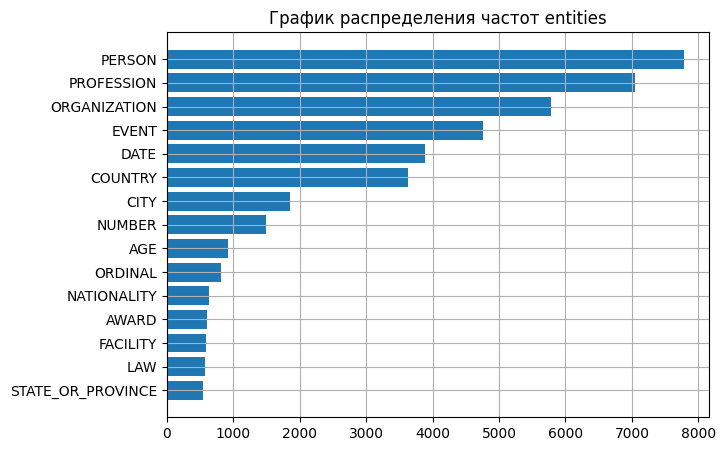

In [12]:
show_bar(entities_count, 'entities')

По графику видно, что можно выделить топ 5 самых популярных сущностей: человек, профессия, организация, события, дата, страна (что объясняется спецификой джатасетов связанных с новостями).

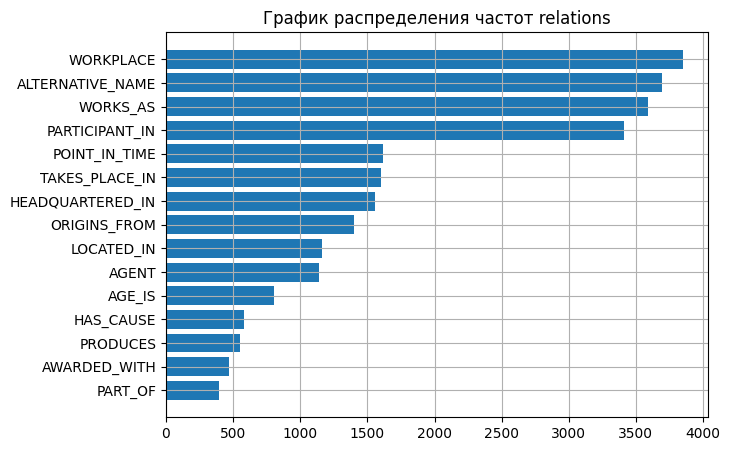

In [13]:
show_bar(relations_count, 'relations')

Под данному графику видно, что выделяется топ 4 самых популярных сущности, причём с большим отрывом.

Выберем ТОП-30 relations именно их мы и будем прогнозировать

In [14]:
top_30_rel = [i[0] for i  in relations_count.most_common(30)]

Посмотрим как распределена длина текстов. Отдельно расмотрим количество символов, количество слов и количество токенов.

In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

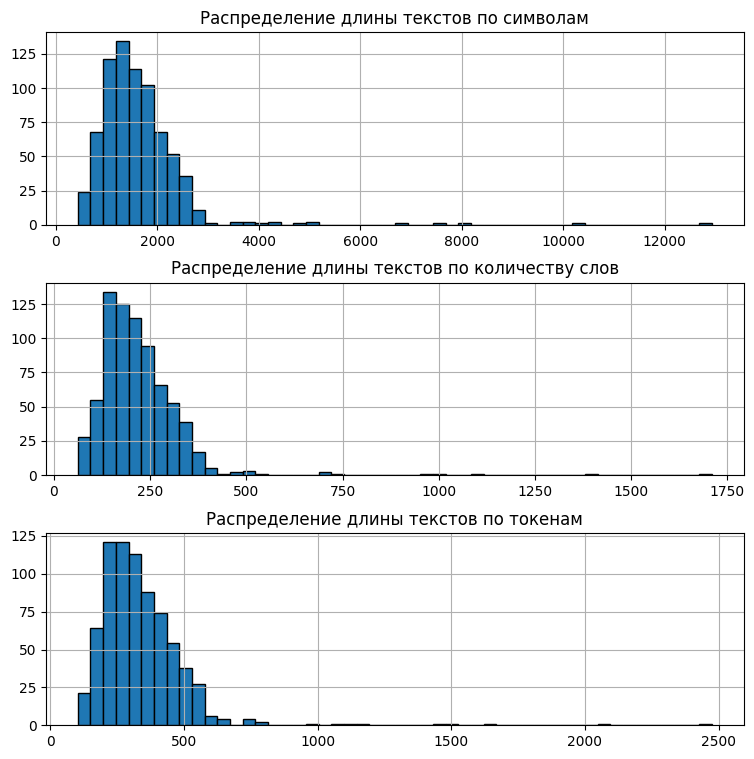

In [16]:
fig, axes = plt.subplots(3, 1, figsize=(9, 9))
plt.subplots_adjust(hspace=0.3)

axes[0].set_title(f"Распределение длины текстов по символам")
axes[0].hist([len(i['text']) for i in train_data], bins=50, edgecolor='black')
axes[0].grid()

axes[1].set_title(f"Распределение длины текстов по количеству слов")
axes[1].hist([len(i['text'].split()) for i in train_data], bins=50, edgecolor='black')
axes[1].grid()

axes[2].set_title(f"Распределение длины текстов по токенам")
axes[2].hist([len(tokenizer(i['text'])['input_ids']) for i in train_data], bins=50, edgecolor='black')
axes[2].grid()

plt.show()


По графикам видно, что все распределения имеют вид близкий к нормальному но с очень больши количеством выбросов:
- Основная часть текстов имеет менее 3000 символов, но еть выбросы даже в районе 13000;
- Большинство текстов имеет менее 400 слов (хотя потом есть небольшое повышение в районе 500 слов), но есть тексты с  более чем 1000 слов;
- Многие тексты укладываются примерно в 500 - 600 токенов, но длина некоторых текстов в токенизированном виде может достигать почти 2500 тысяч, поэтому разумно рассмотреть вариант обрезки текстов в районе 512 токенов.

Рассмотрим как распределены количество сущностей на документ.

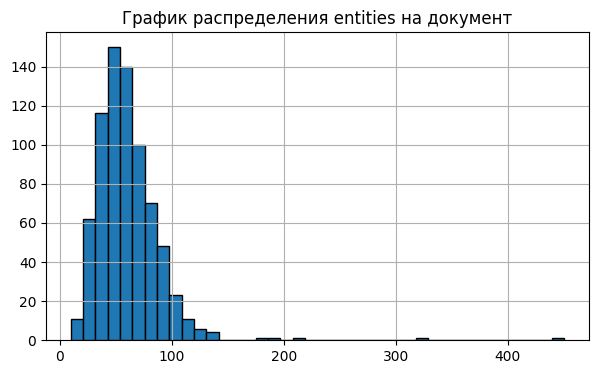

In [17]:
plt.figure(figsize=(7, 4))
plt.title(f'График распределения entities на документ')
plt.hist([len(i['entities']) for i in train_data], bins=40, edgecolor='black')
plt.grid()
plt.show()

В данном случае основная часть распределений имеет вид близкий к нормальному, но также присутсвуют выбросы. При этом можно отметить, что в большинстве случаев количество сущностей на документ не превышает 110.

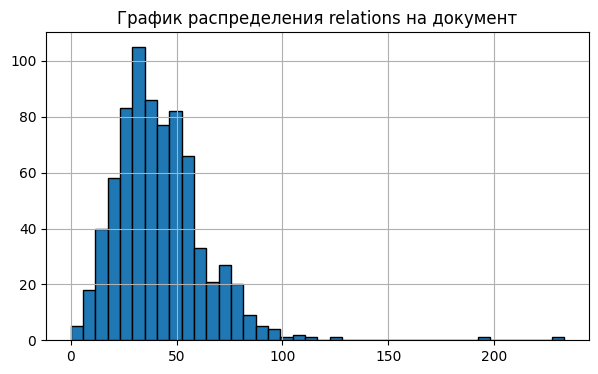

In [18]:
plt.figure(figsize=(7, 4))
plt.title(f'График распределения relations на документ')
plt.hist([len(i['relations']) for i in train_data], bins=40, edgecolor='black')
plt.grid()
plt.show()

Распределени также похоже нанормальное, но имеет более тяжёлый правый хвост и также имеет выбросы. Основная часть документов имеет не более 95 таких сущностей на документ.

### Выводы

Был проведён анализ исходных данных в ходе которого было установлено:
1. Есть очень популярные сущности entities и relations, а есть те, которые встречаются относительно редко.
2. Длины текстов как по символам, так и по количеству слов и токенам в целом имеют распределение близкое к нормальному, если не учитывать выбросы. Сами выбросы могут значительно отстоять от амого распределения и при токенизации целесообразно использовать обрезание длины последовательности.
3. Количество сущностей entities как правило не превышает 110, но тут у нас тоже есть тексты с большим количеством выбросов.
4. Количество сущностей relations как правило не превышает 95 на документ, а в среднем составляет не около 35 сущностей на документ.

## Modeling

В данном разделе нам необходимо преобразовать данные в требуемый формат для обучения и провести само обучение модели.

### Подготовка данных

Напишем функцию для парсинга строкового формата NEREL

In [1]:
def parse_entity_line(line: str):
    parts = line.split('\t')
    if len(parts) < 3:
        return None
    ent_id = parts[0].strip()
    type_pos = parts[1].strip()
    text = parts[2].strip() if len(parts) > 2 else ''
    m = re.match(r'(\S+)\s+(\d+)\s+(\d+)', type_pos)
    if not m:
        return None
    ent_type = m.group(1)
    start = int(m.group(2))
    end = int(m.group(3))
    return {'id': ent_id, 'type': ent_type, 'start': start, 'end': end, 'text': text}

def parse_relation_line(line: str):
    parts = line.split('\t')
    if len(parts) < 2:
        return None
    rel_id = parts[0].strip()
    body = parts[1].strip()
    m = re.match(r'(\S+)\s+Arg1:(\S+)\s+Arg2:(\S+)', body)
    if not m:
        return None
    rel_type = m.group(1)
    arg1 = m.group(2); arg2 = m.group(3)
    return {'id': rel_id, 'type': rel_type, 'arg1': arg1, 'arg2': arg2}

Создадим функцию, которая будет токенизировать по словам и возвращать начало и конец слова.

In [20]:
def tokenize_with_offsets(text: str) -> list[tuple[str, int, int]]:
    offsets = []
    start = 0 
    
    for pos in range(len(text)):
        current_simb = text[pos]
        if current_simb.isalpha() or current_simb.isdigit():
            continue
        elif start != pos:
            end = pos
            offsets.append((text[start:end], start, end))
            start = pos + 1
        else:
            start = pos + 1

    if start != len(text):
        end = len(text)
        offsets.append((text[start:end], start, end))

    return offsets

Напишем функцию, которая будет получать офсеты с токенами, спанами и словарь с сущностями, а возвращать списки токенов, спанов и эгов для BIO.

In [21]:
def get_ofset_and_bio(offsets: list[tuple[str, int, int]], entities: dict) -> dict[str: list]:
    tokens = []
    token_spans = []
    tags = ['O'] * len(offsets)

    curren_pos_ent = 0 # указатель на текую позицию сущности в entities
    current_ent = entities[curren_pos_ent]

    for i, (token, start, end) in enumerate(offsets):
        # Поскольку есть вложенные и пересекающиеся сущности, то в цикле перебираем то того момента
        # пока конец сущности не будет дальше текущего начала спана
        while current_ent is not None and current_ent['end'] < start:
            if curren_pos_ent < len(entities) - 1:
                curren_pos_ent += 1
                current_ent = entities[curren_pos_ent]
            else:
                current_ent = None
                break

        tokens.append(token)
        token_spans.append((start, end))
        
        if current_ent is not None and start == current_ent['start']:
            tags[i] = f"B-{current_ent['type']}"
        elif current_ent is not None and start > current_ent['start'] and end <= current_ent['end']:
            tags[i] = f"I-{current_ent['type']}"

        # if current_ent is not None and end >= current_ent['end']:

    return {'tokens': tokens, 'token_spans': token_spans, 'tags': tags}

Напишем функцию для обработки вложенных сущностей (будем возвращать наиболее длинные)

In [22]:
def clean_entities(entities: list[dict]) -> list[dict]:
    # сортируем записи по начальному индексу
    entities.sort(key=lambda x: x['start'])

    new_entities = []
    current_pos = 0
    current_el = entities[current_pos]
    # проходим по всем сущностям
    while current_pos < len(entities) - 1:
        new_el = entities[current_pos + 1]
        current_diff = current_el['end'] - current_el['start']
        new_diff = new_el['end'] - new_el['start']
        # если новая начало новой сущности находится далье конца текущей, то добавляем как обычно
        if current_el['end'] < new_el['start']:
            new_entities.append(current_el)
            current_el = entities[current_pos + 1]
        # в случае пересечения оставляем ту, которая длинее
        elif new_diff > current_diff:
            current_el = new_el
        current_pos += 1

    # не забываем обработать последнюю сущность
    if current_el['start'] == entities[-1]['start']:
        new_entities.append(current_el)
    return new_entities

Напишем функцию для обработки одной записи.

In [23]:
def processed_one_line(data: dict, mlb: MultiLabelBinarizer) -> dict:
    text = data['text']

    entities = [parse_entity_line(ent) for ent in data['entities']]
    entities = clean_entities(entities)

    relations = [parse_relation_line(rel)['type'] for rel in data['relations']]
    relations = [[rel for rel in relations if rel in top_30_rel]]
    relations = mlb.transform(relations)
    
    offsets = tokenize_with_offsets(text)

    res = get_ofset_and_bio(offsets, entities)    
    res['text'] = text
    res['cls_vec'] = relations.flatten().tolist()

    return res


Проинициализируем MultiLabelBinarizer (он потребуется чтобы получать вектор с метками классов для мультилейбла). Также получим справочник со всеми метками, чтобы не возникало проблем при кодировке.

In [24]:
rel_type = []
with open(PATH_REL, 'r', encoding='utf-8') as file:
    for line in file:
        rel_type.append(json.loads(line.strip()))

mlb = MultiLabelBinarizer()
mlb.fit([set(top_30_rel)])

,"classes classes: array-like of shape (n_classes,), default=NoneIndicates an ordering for the class labels.All entries should be unique (cannot contain duplicate classes).",None
,"sparse_output sparse_output: bool, default=FalseSet to True if output binary array is desired in CSR sparse format.",False


Напишем результирующую функцию, которая обработает все наши записи.

In [25]:
def build_examples_from_nerel(records: list[dict], mlb: MultiLabelBinarizer) -> list[dict]:
    res = []
    for record in tqdm(records, desc='Обработка записей'):
        res.append(processed_one_line(record, mlb))
    return res

In [26]:
res = build_examples_from_nerel(train_data, mlb)

Обработка записей: 100%|██████████| 746/746 [00:00<00:00, 1999.30it/s]


Выведем информацию по 5 случайным записям. Для воспроизводимости завиксируем сиды. Также будем выводить только первые 150 символов по текстам и 20 сэмплов по остальным спискам (чтобы вывод был читаемый)

In [27]:
random.seed(SEED)
np.random.seed(SEED)
inds = np.random.randint(0, len(res), 5)
for ind in inds:
    print(res[ind]['text'][:150])
    print(res[ind]['tokens'][:20])
    print(res[ind]['token_spans'][:20])
    print(res[ind]['tags'][:20])
    print(res[ind]['cls_vec'])
    print('\n')
    print('-' * 50)

Странное преступление против семьи россиян в Аргентине



Прокурор района Морено в Буэнос Айресе, начал расследование убийства Людмилы Касьян, застрел
['Странное', 'преступление', 'против', 'семьи', 'россиян', 'в', 'Аргентине', 'Прокурор', 'района', 'Морено', 'в', 'Буэнос', 'Айресе', 'начал', 'расследование', 'убийства', 'Людмилы', 'Касьян', 'застреленной', 'в']
[(0, 8), (9, 21), (22, 28), (29, 34), (35, 42), (43, 44), (45, 54), (58, 66), (67, 73), (74, 80), (81, 82), (83, 89), (90, 96), (98, 103), (104, 117), (118, 126), (127, 134), (135, 141), (143, 155), (156, 157)]
['O', 'O', 'O', 'O', 'B-NATIONALITY', 'O', 'B-COUNTRY', 'B-PROFESSION', 'O', 'B-DISTRICT', 'O', 'B-CITY', 'I-CITY', 'O', 'B-EVENT', 'I-EVENT', 'B-PERSON', 'I-PERSON', 'O', 'O']
[0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0]


--------------------------------------------------
Пакистанец, подозреваемый в терроризме, предстал перед судом в США
Схема нью-йоркского метрополитена.
В

Исходя из примеров можно сделать вывод, что преобразование произошло корректно.

Разделим полученные данные на тренировочне и валидационные в отношении 85 на 15.

In [28]:
random.seed(SEED)
random.shuffle(res)
split_indx= int(len(res) * 0.85)
train_data = res[:split_indx]
valid_data = res[split_indx:]

Так же вычитаем тестовые данные и сделаем с ними те же преобразования.

In [29]:
test_data = []
with open(PATH_TEST, 'r', encoding='utf-8') as file:
    for line in file:
        test_data.append(json.loads(line.strip()))

In [30]:
test_data = build_examples_from_nerel(test_data, mlb)

Обработка записей: 100%|██████████| 93/93 [00:00<00:00, 1887.95it/s]


Выведем размеры получившихся данных

In [31]:
len(train_data), len(valid_data), len(test_data)

(634, 112, 93)

Создадим объединённый список данных, который понадобиться нам для получения полного списка лейблов

In [32]:
all_data = train_data + valid_data + test_data

Теперь нам необходимо провести токенизацию и выравнивание меток.

Создадим словари для дальнейшей кодировки лейблов в id  и обратно.

In [33]:
unique_labels = set()
for data in all_data:
    unique_labels.update(data["tags"])
unique_labels.add("O")
label_list = sorted(unique_labels)
label2id = {lab: i for i, lab in enumerate(label_list)}
id2label = {i: lab for lab, i in label2id.items()}

Проведём преобразование данных во всех датасетах.

In [34]:
for data in train_data:
    data["tags"] = [label2id[t] for t in data["tags"]]
for data in valid_data:
    data["tags"] = [label2id[t] for t in data["tags"]]
for data in test_data:
    data["tags"] = [label2id[t] for t in data["tags"]]

Получим датасет для дальнейшей работы.

In [35]:
dataset = DatasetDict({"train": Dataset.from_list(train_data),
                       "valid": Dataset.from_list(valid_data),
                       "test": Dataset.from_list(test_data)})
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'text', 'cls_vec'],
        num_rows: 634
    })
    valid: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'text', 'cls_vec'],
        num_rows: 112
    })
    test: Dataset({
        features: ['tokens', 'token_spans', 'tags', 'text', 'cls_vec'],
        num_rows: 93
    })
})


Напишем функцию, для получения инпутов с масками внимания, а также с лейблами для задачи NER и классификации.

In [36]:
def tokenize_and_align_labels(examples, tokenizer, max_length):
    tokenized = tokenizer(
        examples["tokens"],
        is_split_into_words=True,
        truncation=True,
        padding="max_length",
        max_length=max_length
    )
    labels = []
    for i, word_labels in enumerate(examples["tags"]):
        word_ids = tokenized.word_ids(batch_index=i)
        label_ids = []
        prev_word_idx = None
        for word_idx in word_ids:
            if word_idx is None:
                label_ids.append(-100)
            elif word_idx != prev_word_idx:
                label_ids.append(word_labels[word_idx])
            else:
                label_ids.append(-100)
            prev_word_idx = word_idx
        labels.append(label_ids)
    
    cls_labels = []
    for cls in examples['cls_vec']:
        cls_labels.append(cls)

    tokenized["labels"] = labels
    tokenized["cls_labels"] = cls_labels
    return tokenized

Применим к датасету и посмотрим на результат.

In [37]:
tokenized_dataset = dataset.map(
    tokenize_and_align_labels,
    fn_kwargs={'tokenizer': tokenizer, 'max_length': 512},
    batched=True,
    remove_columns=['tokens', 'token_spans', 'tags', 'text', 'cls_vec']
)

print(tokenized_dataset)
print(tokenized_dataset['train'][0])

Map:   0%|          | 0/634 [00:00<?, ? examples/s]

Map:   0%|          | 0/112 [00:00<?, ? examples/s]

Map:   0%|          | 0/93 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'cls_labels'],
        num_rows: 634
    })
    valid: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'cls_labels'],
        num_rows: 112
    })
    test: Dataset({
        features: ['input_ids', 'token_type_ids', 'attention_mask', 'labels', 'cls_labels'],
        num_rows: 93
    })
})
{'input_ids': [101, 24602, 9199, 1150, 2135, 29530, 928, 378, 38419, 13447, 49750, 24639, 45763, 12198, 15402, 16080, 114, 11278, 29530, 8836, 11142, 38419, 13447, 49750, 29251, 9903, 57426, 50055, 113, 7790, 979, 2270, 61712, 33865, 31274, 24606, 376, 378, 4949, 48875, 2241, 13323, 918, 45343, 34150, 1593, 13590, 114, 26121, 815, 107, 93135, 9170, 1762, 33847, 1919, 3234, 944, 752, 378, 2992, 667, 378, 14092, 6698, 113, 8674, 979, 1040, 95975, 4167, 63176, 51938, 110, 22284, 14016, 29062, 655, 3581, 652, 37117, 113, 13233, 979, 1374, 4885, 110, 4529

Создадим соответствующие даталоадеры.

In [38]:
data_collator = DataCollatorForTokenClassification(tokenizer)

train_dataloader = DataLoader(
    tokenized_dataset["train"],
    batch_size=16,
    shuffle=True,
    collate_fn=data_collator
)

valid_dataloader = DataLoader(
    tokenized_dataset["valid"],
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

test_dataloader = DataLoader(
    tokenized_dataset["test"],
    batch_size=16,
    shuffle=False,
    collate_fn=data_collator
)

### Создание модели и лоссов.

Создадим модель для нашей задачи, предусмотрим наличие у неё двух голов, одны для NER другая для CLS.

In [39]:
class JointModel(nn.Module):
    def __init__(self, name_model, num_labels_ner, num_labels_cls, dropout=0.5):
        super().__init__()
        self.bert = AutoModel.from_pretrained(name_model)
        hidden_size = self.bert.config.hidden_size
        
        self.dropout_ner1 = nn.Dropout(dropout)
        self.dropout_ner2 = nn.Dropout(dropout)
        self.dropout_cls1 = nn.Dropout(dropout)
        
        self.ner1 = nn.Linear(hidden_size, hidden_size * 2)
        self.ner2 = nn.Linear(hidden_size * 2, num_labels_ner)
        self.cls = nn.Linear(hidden_size, num_labels_cls)
        self.gelu = nn.GELU()
        
    def forward(self, input_ids, token_type_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids, 
            token_type_ids=token_type_ids, 
            attention_mask=attention_mask
        )
        
        # NER head
        ner_out = self.dropout_ner1(outputs.last_hidden_state)
        ner_out = self.ner1(ner_out)
        ner_out = self.gelu(ner_out)
        ner_out = self.dropout_ner2(ner_out)
        ner_out = self.ner2(ner_out)
                
        # CLS head
        cls_out = self.dropout_cls1(outputs.pooler_output)
        cls_out = self.cls(cls_out)
        
        return {
            'ner_logits': ner_out,
            'cls_logits': cls_out
        }

Как мы видели при анализе данных у нас сильный дисбаланс классов, это необходимо учесть инициализации лоссов (Для классификации используем ассимитричный лосс, чтобы учесть дисбаланс).

In [41]:
bio = []
[bio.extend(data['tags']) for data in train_data]
bio_count = Counter(bio)

In [42]:
weight_ner = np.array([bio_count[i] for i in range(len(label2id))])
weight_ner[weight_ner==0] = weight_ner.mean()
# weight_ner = 1 / (weight_ner + 1)
weight_ner = 1 / np.sqrt(weight_ner + 1)
weight_ner = weight_ner / weight_ner.sum()
weight_ner = torch.tensor(weight_ner, dtype=torch.float32)

Для NER задачи нам потребуется лосс на базе кроссэнтропии, но необходимо будет учитывать так же маску внимания, поскольку есть относительно короткие строки и паддинг может исказить на них лосс. В качестве лосса для мультилейбловой классификации будем использовать ассимитричный лосс. Поскольку лоссы могут иметь разный масштаб и они могу по разному влиять на финальный результат, то объединим их в один с учётом весов, которые будут обновляться в процессе обучения.

In [ ]:
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg = gamma_neg
        self.gamma_pos = gamma_pos
        self.clip = clip
        self.eps = eps

    def forward(self, logits, targets):
        logits = logits.float()
        targets = targets.float()
        xs_pos = torch.sigmoid(logits)
        xs_neg = 1 - xs_pos

        if self.clip is not None and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        los_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        los_neg = (1 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = los_pos + los_neg

        pt = torch.where(targets == 1, xs_pos, xs_neg)
        one_sided_gamma = torch.where(targets == 1, self.gamma_pos, self.gamma_neg)
        one_sided_w = torch.pow(1 - pt, one_sided_gamma)

        loss *= one_sided_w
        return -loss.sum(dim=1).mean()


class CustomLoss(nn.Module):
    def __init__(self, num_labels_ner, device):
        super().__init__()
        self.num_labels_ner = num_labels_ner
        self.log_sigma_token = nn.Parameter(torch.tensor(0.0))
        self.log_sigma_cls = nn.Parameter(torch.tensor(0.0)) 
        self.device = device

    def loss_ner(self, logits, labels, attention_mask):
        active_loss = attention_mask.view(-1) == 1
        active_logits = logits.view(-1, self.num_labels_ner)[active_loss]
        active_labels = labels.view(-1)[active_loss]

        loss = nn.CrossEntropyLoss(weight=weight_ner.to(self.device), ignore_index=-100)(active_logits, active_labels)
        return loss
        
    def loss_cls(self, logits, labels):
        return AsymmetricLoss()(logits, labels)
    
    def forward(self, logits_ner, labels_ner, attention_mask_ner, logits_cls, labels_cls):
        ner_loss = self.loss_ner(logits_ner, labels_ner, attention_mask_ner)
        cls_loss = self.loss_cls(logits_cls, labels_cls)

        loss_token_term = torch.exp(-2.0 * self.log_sigma_token) * ner_loss + self.log_sigma_token
        loss_cls_term = torch.exp(-2.0 * self.log_sigma_cls) * cls_loss + self.log_sigma_cls
        loss = loss_token_term + loss_cls_term + 0.01 * (self.log_sigma_token**2 + self.log_sigma_cls**2)
        return loss

Напишем функцию, которая будет преобразовывать прогнозы по NER и лейблы в плоские списки в рамках одного батча, нам это потребует ся в дальнейшем для получения метрик.

In [44]:
def get_flat_labels_and_preds_ner(logits, true_labels):
    preds = torch.argmax(logits, dim=-1).squeeze(0).cpu().tolist() 
    true_labels = true_labels.cpu()
    y_true = []
    y_pred = []
    # Фильтруем позиции, где true != -100
    filtered_true = []
    filtered_pred = []
    for pred, label in zip(preds, true_labels):
        for p, t in zip(pred, label):
            if t == -100:
                continue
            filtered_true.append(int(t))
            filtered_pred.append(int(p))

    # Обрежем на минимальную длину (на случай рассинхронизации)
    minlen = min(len(filtered_true), len(filtered_pred))
    if minlen != 0:
        y_true = filtered_true[:minlen]
        y_pred = filtered_pred[:minlen]
    return y_true, y_pred

Также создадим функцию для выходов классификатора (будем относить к положительной метки класса логиты после сигмоиды, которые выше 0.5)

In [45]:
def get_labels_and_preds_cls(logits, true_labels, treshold=0.5):
    preds = torch.sigmoid(logits).cpu().detach().numpy()
    preds = (preds >= treshold).astype(int)
    true_labels = true_labels.cpu().detach().numpy().astype(int)
    return true_labels, preds

### Обучение и валидация модели

Укажем константы, которые позволят управлять ходомобучения.

In [46]:
VERBOSE = 5
PATIENCE = 10
LR = 5e-5
LR_LOSS = LR * 10
EPOCHS = 50

Напишем функцию для фиксации сидов, для воспроизводимости результатов.

In [47]:
def fix_seed(seed: int):
    random.seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.benchmark = True

При обучении будем мониторить поведение метрики f1, причём для NER будем использовать усреднение macro, а для классификации micro (поскольку, как мы помним из анализа у нас есть ряд классов, которые очень часто встречаются в датасете и нам важно в них не ошибаться, в то время как ошибится в очень редких классах не так критично).

Напишем функцию для тренировки одной эпохи.

In [48]:
def train_one_epoch(model, optimizer_model, loss_fn, optimizer_loss, train_loader, device):

    y_true_ner_list, y_pred_ner_list = [], []
    y_true_cls_list, y_pred_cls_list = [], []

    model.train()
    total_loss = 0.0

    for batch in train_loader:
        fix_seed(SEED)

        input_ids = batch['input_ids'].to(device)
        token_type_ids = batch['token_type_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels_ner = batch['labels'].to(device)
        labels_cls = batch['cls_labels'].to(device, dtype = torch.float)

        optimizer_model.zero_grad()
        optimizer_loss.zero_grad()

        output = model(input_ids, token_type_ids, attention_mask)
        loss = loss_fn(output['ner_logits'], labels_ner, attention_mask, output['cls_logits'], labels_cls)
        
        loss.backward()
        optimizer_loss.step()
        optimizer_model.step()

        total_loss += loss.item()
        y_true_ner, y_pred_ner = get_flat_labels_and_preds_ner(output['ner_logits'], labels_ner)
        y_true_cls, y_pred_cls = get_labels_and_preds_cls(output['cls_logits'], labels_cls)

        y_true_ner_list.extend(y_true_ner) 
        y_pred_ner_list.extend(y_pred_ner)
        y_true_cls_list.append(y_true_cls)
        y_pred_cls_list.append(y_pred_cls)

    f1_ner = f1_score(y_true_ner_list, y_pred_ner_list, average='macro')
    f1_cls = f1_score(np.concatenate(y_true_cls_list), np.concatenate(y_pred_cls_list), average='micro')

    train_loss = total_loss/len(train_loader)
    return train_loss, f1_ner, f1_cls

Напишем функцию для валидации

In [49]:
def valid(model, loss_fn, loader, device):

    y_true_ner_list, y_pred_ner_list = [], []
    y_true_cls_list, y_pred_cls_list = [], []

    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for batch in loader:

            input_ids = batch['input_ids'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_ner = batch['labels'].to(device)
            labels_cls = batch['cls_labels'].to(device, dtype = torch.float)

            output = model(input_ids, token_type_ids, attention_mask)
            loss = loss_fn(output['ner_logits'], labels_ner, attention_mask, output['cls_logits'], labels_cls)
            total_loss += loss.item()
            
            y_true_ner, y_pred_ner = get_flat_labels_and_preds_ner(output['ner_logits'], labels_ner)
            y_true_cls, y_pred_cls = get_labels_and_preds_cls(output['cls_logits'], labels_cls)

            y_true_ner_list.extend(y_true_ner) 
            y_pred_ner_list.extend(y_pred_ner)
            y_true_cls_list.append(y_true_cls)
            y_pred_cls_list.append(y_pred_cls)

    f1_ner = f1_score(y_true_ner_list, y_pred_ner_list, average='macro')
    f1_cls = f1_score(np.concatenate(y_true_cls_list), np.concatenate(y_pred_cls_list), average='micro')

    val_loss = total_loss/len(loader)
    return val_loss, f1_ner, f1_cls

Проинициализируем модель, лосс, оптимизаторы и график для лосса модели.

In [50]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [51]:
model = JointModel(MODEL_NAME, len(label2id), len(mlb.classes_), 0.5).to(device)
loss_fn = CustomLoss(len(label2id), device).to(device)

Создадим оптимизаторы и график изменения шага обучения

In [52]:
no_decay = ['bias', 'LayerNorm.weight', 'layer_norm.weight']  # типичные имена
optimizer_grouped_parameters = [
    {
        'params': [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        'weight_decay': 0.5
    },
    {
        'params': [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        'weight_decay': 0.0
    }
]

optimizer_model = optim.AdamW(optimizer_grouped_parameters, lr=LR)
optimizer_loss = optim.Adam(params=loss_fn.parameters(), lr=LR_LOSS, weight_decay=0)

In [ ]:
# Создаём графики измения lr (разогревающий и косинусный для снижения)
# Warmup
warmup_scheduler = LinearLR(
    optimizer_model, 
    start_factor=1e-5,
    end_factor=1.0,
    total_iters=5
)

# Cosine annealing
cosine_scheduler = CosineAnnealingLR(
    optimizer_model, 
    T_max=EPOCHS-5,                        
    eta_min=LR * 1e-5     
)

# Комбинируем
scheduler = SequentialLR(
    optimizer_model,
    schedulers=[warmup_scheduler, cosine_scheduler],
    milestones=[5]       # переключение после 5 эпохи
)   

Напишем цикл обучения, Предусмотрим раннюю остановку, если лосс обе метрики не будет улучшаться.

In [54]:
# инициализируем переменные и списки
best_val_loss = np.inf
best_epoch = 0
best_f1_cls_v = 0
best_f1_ner_v = 0
no_improove = 0
train_losses = []
val_losses = []
f1_ner_train = []
f1_cls_train = []
f1_ner_val = []
f1_cls_val = []
lrs = []

log_sigma_cls = []
log_sigma_token = []

print("training started")
for epoch in range(EPOCHS):
    train_loss, f1_ner_t, f1_cls_t  = train_one_epoch(model, optimizer_model, loss_fn, optimizer_loss, train_dataloader, device)
    val_loss, f1_ner_v, f1_cls_v = valid(model, loss_fn, valid_dataloader, device)

    scheduler.step()

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    f1_ner_train.append(f1_ner_t)
    f1_cls_train.append(f1_cls_t)
    f1_ner_val.append(f1_ner_v)
    f1_cls_val.append(f1_cls_v)
    lrs.append(scheduler.get_last_lr()[0])

    log_sigma_cls.append(loss_fn.log_sigma_cls.item())
    log_sigma_token.append(loss_fn.log_sigma_token.item())

    if VERBOSE == 0 or epoch % VERBOSE == 0:
        print(
            f"Epoch {epoch + 1}/{EPOCHS} | train_Loss: {train_loss:.4f} | val_Loss: {val_loss:.4f} | Train f1 NER: {f1_ner_t :.4f} | Val f1 NER: {f1_ner_v :.4f} | Train f1 CLS: {f1_cls_t :.4f} | Val f1 CLS: {f1_cls_v :.4f}"
        )

    # if val_loss < best_val_loss:
    #     best_val_loss = val_loss
    #     best_epoch = epoch
    #     torch.save(model.state_dict(), SAVE_MODEL_PATH)
    #     no_improove = 0
    # else:
    #     no_improove += 1

    if f1_cls_v > best_f1_cls_v and f1_ner_v > best_f1_ner_v:
        best_f1_cls_v = f1_cls_v
        best_f1_ner_v = f1_ner_v
        best_epoch = epoch
        torch.save(model.state_dict(), SAVE_MODEL_PATH)
        no_improove = 0
    else:
        no_improove += 1


    if no_improove > PATIENCE:            
        print(f"No improvement in validation loss for {PATIENCE} epochs, stopping...")
        break

training started
Epoch 1/50 | train_Loss: 9.0598 | val_Loss: 8.5338 | Train f1 NER: 0.0079 | Val f1 NER: 0.0068 | Train f1 CLS: 0.4496 | Val f1 CLS: 0.4519
Epoch 6/50 | train_Loss: 3.7848 | val_Loss: 4.0880 | Train f1 NER: 0.1769 | Val f1 NER: 0.2456 | Train f1 CLS: 0.7400 | Val f1 CLS: 0.6937
Epoch 11/50 | train_Loss: 1.3403 | val_Loss: 3.0240 | Train f1 NER: 0.7642 | Val f1 NER: 0.6070 | Train f1 CLS: 0.8754 | Val f1 CLS: 0.7420
Epoch 16/50 | train_Loss: 0.6731 | val_Loss: 3.1544 | Train f1 NER: 0.9659 | Val f1 NER: 0.6843 | Train f1 CLS: 0.9456 | Val f1 CLS: 0.7599
Epoch 21/50 | train_Loss: 0.4060 | val_Loss: 4.0302 | Train f1 NER: 0.9911 | Val f1 NER: 0.6830 | Train f1 CLS: 0.9871 | Val f1 CLS: 0.7529
Epoch 26/50 | train_Loss: 0.2715 | val_Loss: 4.0490 | Train f1 NER: 0.9957 | Val f1 NER: 0.6892 | Train f1 CLS: 0.9955 | Val f1 CLS: 0.7640
Epoch 31/50 | train_Loss: 0.1555 | val_Loss: 5.1370 | Train f1 NER: 0.9988 | Val f1 NER: 0.6880 | Train f1 CLS: 0.9992 | Val f1 CLS: 0.7522
Epoch

In [55]:
loss_fn.log_sigma_cls

Parameter containing:
tensor(-0.0429, device='cuda:0', requires_grad=True)

In [56]:
loss_fn.log_sigma_token

Parameter containing:
tensor(-0.0971, device='cuda:0', requires_grad=True)

Построим графики измекнения лоссов, шага обучения и метрик.

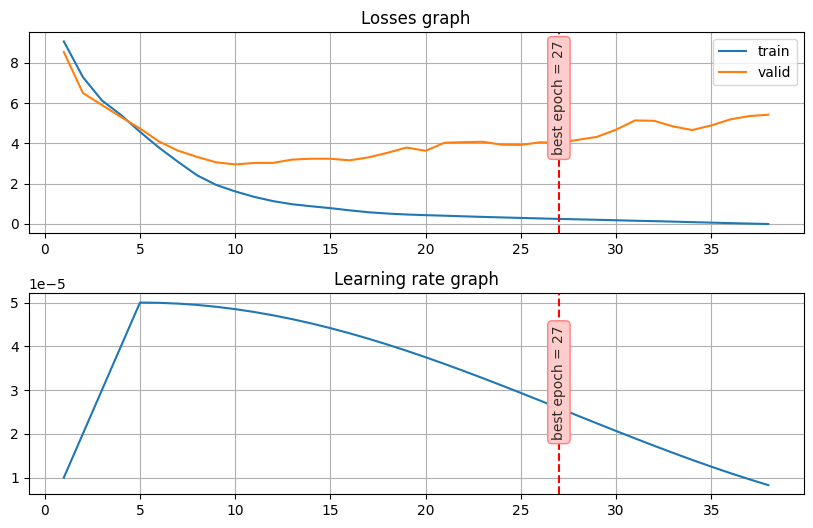

In [62]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plt.subplots_adjust(hspace=0.3)

axes[0].set_title(f"Losses graph")
axes[0].plot(list(range(1, len(train_losses) + 1)), train_losses, label='train')
axes[0].plot(list(range(1, len(val_losses) + 1)), val_losses, label='valid')
axes[0].axvline(best_epoch + 1, linestyle='--', color='r')
axes[0].legend()
axes[0].grid()
axes[0].text(best_epoch + 1,
            max([min(train_losses), min(val_losses)]) + 0.05 * (max(train_losses) - min(train_losses)),
            f'best epoch = {best_epoch + 1}',
            size=10,
            alpha=0.8,
            rotation='vertical',
            ha="center",
            va="bottom",
            bbox=dict(boxstyle="round",
                    ec=(1., 0.5, 0.5),
                    fc=(1., 0.8, 0.8),
                    )
            )

axes[1].set_title(f"Learning rate graph")
axes[1].plot(list(range(1, len(lrs) + 1)), lrs)
axes[1].axvline(best_epoch + 1, linestyle='--', color='r')
axes[1].grid()
axes[1].text(best_epoch + 1,
            min(lrs) + 0.25 * (max(lrs) - min(lrs)),
            f'best epoch = {best_epoch + 1}',
            size=10,
            alpha=0.8,
            rotation='vertical',
            ha="center",
            va="bottom",
            bbox=dict(boxstyle="round",
                    ec=(1., 0.5, 0.5),
                    fc=(1., 0.8, 0.8),
                    )
            )

plt.show()

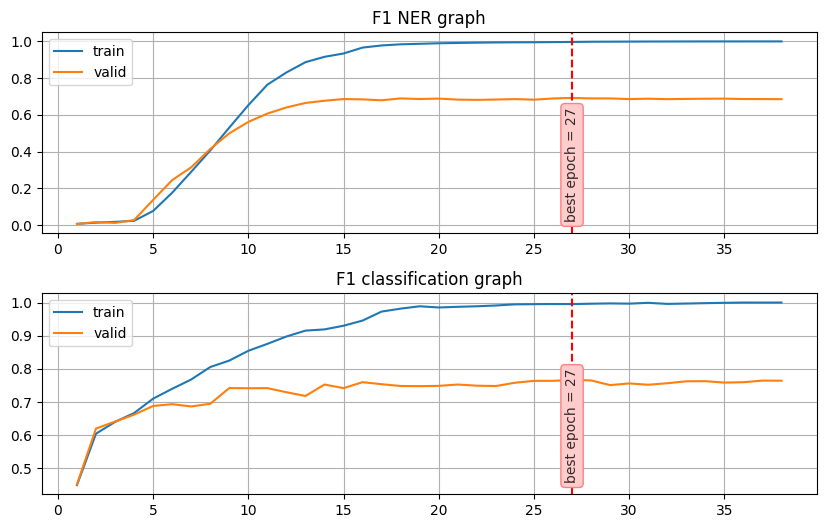

In [58]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6))
plt.subplots_adjust(hspace=0.3)

axes[0].set_title(f"F1 NER graph")
axes[0].plot(list(range(1, len(f1_ner_train) + 1)), f1_ner_train, label='train')
axes[0].plot(list(range(1, len(f1_ner_val) + 1)), f1_ner_val, label='valid')
axes[0].axvline(best_epoch + 1, linestyle='--', color='r')
axes[0].legend()
axes[0].grid()
axes[0].text(best_epoch + 1,
            min([min(f1_ner_train), min(f1_ner_val)]) + 0.01 * (max(f1_ner_train + f1_ner_val) - min(f1_ner_train + f1_ner_val)),
            f'best epoch = {best_epoch + 1}',
            size=10,
            alpha=0.8,
            rotation='vertical',
            ha="center",
            va="bottom",
            bbox=dict(boxstyle="round",
                    ec=(1., 0.5, 0.5),
                    fc=(1., 0.8, 0.8),
                    )
            )

axes[1].set_title(f"F1 classification graph")
axes[1].plot(list(range(1, len(f1_cls_train) + 1)), f1_cls_train, label='train')
axes[1].plot(list(range(1, len(f1_cls_val) + 1)), f1_cls_val, label='valid')
axes[1].axvline(best_epoch + 1, linestyle='--', color='r')
axes[1].legend()
axes[1].grid()
axes[1].text(best_epoch + 1,
            min([min(f1_cls_train), min(f1_cls_val)]) + 0.01 * (max(f1_cls_train + f1_cls_val) - min(f1_cls_train + f1_cls_val)),
            f'best epoch = {best_epoch + 1}',
            size=10,
            alpha=0.8,
            rotation='vertical',
            ha="center",
            va="bottom",
            bbox=dict(boxstyle="round",
                    ec=(1., 0.5, 0.5),
                    fc=(1., 0.8, 0.8),
                    )
            )

plt.show()

Выведем значение лучших метрик на валидации.

In [59]:
f1_ner_val[best_epoch], f1_cls_val[best_epoch]

(0.6922561097835599, 0.7666781887314207)

Сеть обучилась, хотя результаты не однозначные. Лосс на валидации перестаёт улучшаться, а  метрики растут, поэтому раннюю остановку делаем именно по метрикам, это позволит получить модель немного лучшего качества.

## Инференс, квантизация и анализ ошибок

Посмотрим как наша модель покажет сеяб на тестовом наборе данных, которые она никогда не видела. Для этого загрузим лучшую модель.

In [63]:
model.load_state_dict(torch.load(SAVE_MODEL_PATH, weights_only=True))

<All keys matched successfully>

Напишем функцию для инференса, она будет похожа на валидационную функцию, но будет возвращать прогнозы и лейблы для тестового датасета, и сразу выводить значение метрики F1 для данных.

In [64]:
def eval(model, loader, device):

    y_true_ner_list, y_pred_ner_list = [], []
    y_true_cls_list, y_pred_cls_list = [], []

    model.eval()

    with torch.no_grad():
        for batch in loader:

            input_ids = batch['input_ids'].to(device)
            token_type_ids = batch['token_type_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            labels_ner = batch['labels'].to(device)
            labels_cls = batch['cls_labels'].to(device, dtype = torch.float)

            output = model(input_ids, token_type_ids, attention_mask)
            
            y_true_ner, y_pred_ner = get_flat_labels_and_preds_ner(output['ner_logits'], labels_ner)
            y_true_cls, y_pred_cls = get_labels_and_preds_cls(output['cls_logits'], labels_cls)

            y_true_ner_list.extend(y_true_ner) 
            y_pred_ner_list.extend(y_pred_ner)
            y_true_cls_list.append(y_true_cls)
            y_pred_cls_list.append(y_pred_cls)

    f1_ner = f1_score(y_true_ner_list, y_pred_ner_list, average='macro')
    f1_cls = f1_score(np.concatenate(y_true_cls_list), np.concatenate(y_pred_cls_list), average='micro')
    print(f"f1 NER: {f1_ner :.4f}\nf1 CLS: {f1_cls :.4f}")
    return y_true_ner_list, y_pred_ner_list, np.concatenate(y_true_cls_list), np.concatenate(y_pred_cls_list)

In [65]:
y_true_ner, y_pred_ner, y_true_cls, y_pred_cls = eval(model, test_dataloader, device)

f1 NER: 0.6867
f1 CLS: 0.7496


Значения f1 неплохие, и соответствуют результатам на валидации. 

Помсотрим на матрицу ошибок для NER для цветовой шкалы установим vmax=50, это сделает карту более читабельной и оставим только те классы в которых есть ошибки.

In [66]:
labels = list(id2label.values())
named_y_true = [id2label[i] for i in y_true_ner]
named_y_pred = [id2label[i] for i in y_pred_ner]

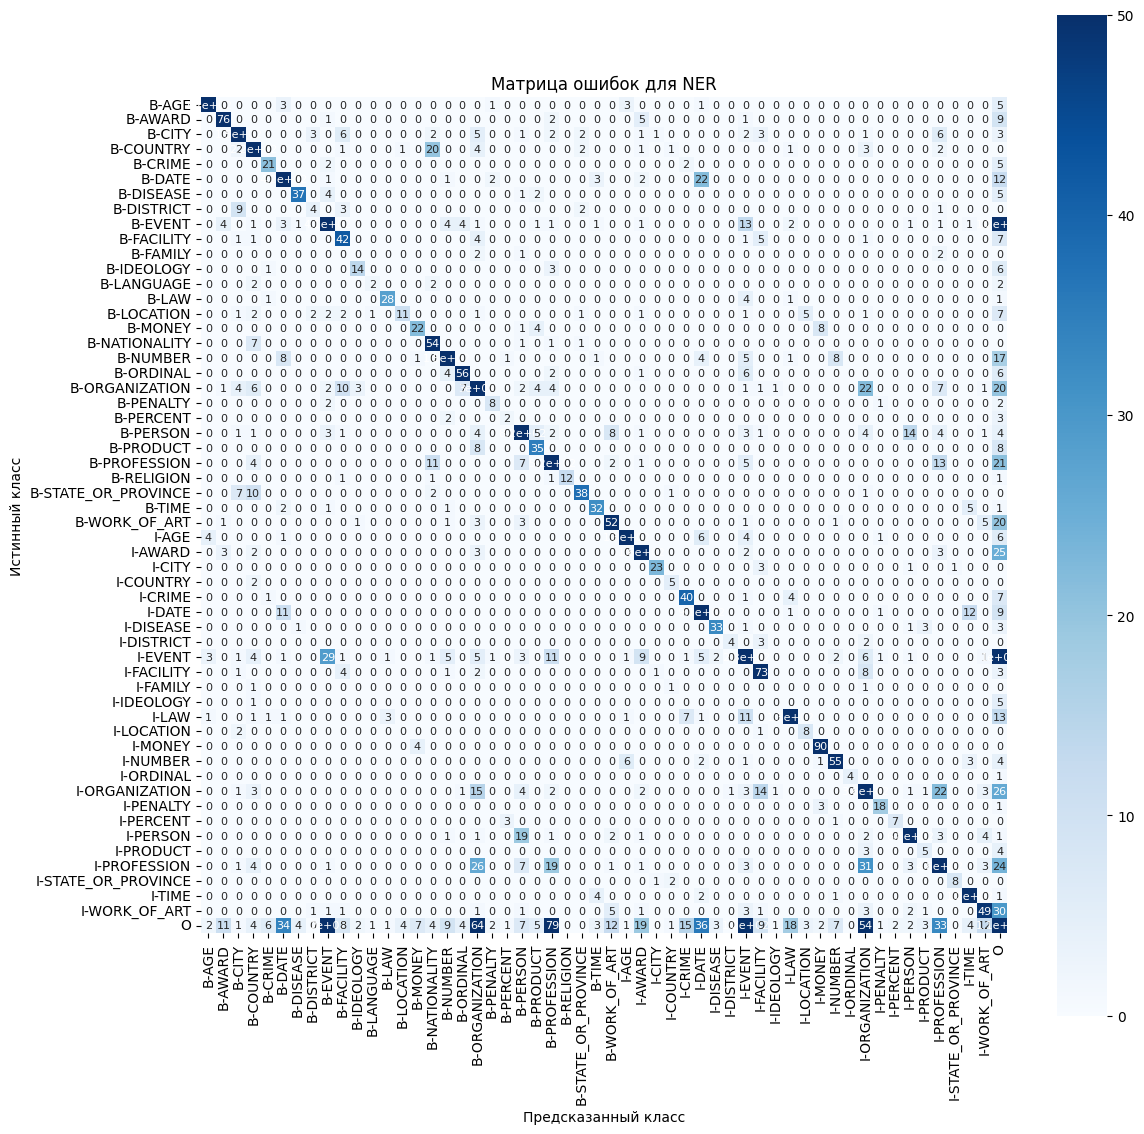

In [67]:
cm = confusion_matrix(named_y_true, named_y_pred, labels=labels)
mask_y = (cm==0).sum(axis=1) < len(labels) - 1 # оставим только те, в которых есть ошибки классификации.
cm = cm[mask_y]
label_y = np.array(labels)[mask_y].tolist()

mask_x = (cm==0).sum(axis=0) < len(label_y) # оставим только те, c которыми путаются другие.
cm = cm[:, mask_x]

plt.figure(figsize=(13, 13))
sns.heatmap(cm, annot=True, cmap="Blues", square=True, yticklabels=label_y, xticklabels=np.array(labels)[mask_x].tolist(), annot_kws={"fontsize": 8}, vmax=50)
plt.xlabel('Предсказанный класс')
plt.ylabel('Истинный класс')
plt.title('Матрица ошибок для NER')
plt.show()

Чаще всего путаются классы для слов без разметки (О). Иногда объекты данного класса относятся к сущностям, иногда наоборот сущности относятся к данному классу. Самые большие проблемы у сущностей event, поскольку зачастую действие и событие может иметь специализированную разметку, а может и не иметь (вероятнее всего это проблема разметки самих данных). Так же есть проблемы в разделении где заканчивается профессия и где начинается организация, но это тоже может быть связано с первоначальной разметкой. Кроме того наблюдаются ошибки с токенами начала / продолжения сущности (например начало организации или профессии может быть ошибочно поставлено вместо токена продолжения).

Для классификации построим отчёт для классификации.

In [68]:
print(classification_report(y_true_cls, y_pred_cls, target_names=mlb.classes_))

                    precision    recall  f1-score   support

      ABBREVIATION       0.25      0.16      0.19        19
             AGENT       0.51      0.93      0.66        44
            AGE_IS       0.74      0.97      0.84        66
  ALTERNATIVE_NAME       0.94      1.00      0.97        87
      AWARDED_WITH       0.44      0.67      0.53        24
      CONVICTED_OF       0.70      0.58      0.64        12
        FOUNDED_BY       0.62      0.28      0.38        18
         HAS_CAUSE       0.81      0.74      0.77        39
  HEADQUARTERED_IN       0.72      0.94      0.82        62
       IDEOLOGY_OF       0.29      0.36      0.32        14
INANIMATE_INVOLVED       0.36      0.86      0.51        22
             KNOWS       0.28      0.47      0.35        15
        LOCATED_IN       0.83      0.81      0.82        62
 MEDICAL_CONDITION       0.71      0.80      0.75        15
         MEMBER_OF       0.21      0.29      0.24        14
         ORGANIZES       0.56      0.26

Как видим для частых классов (с вхождениями семплов больше 60) модель справляется хорошо, но с редкими классами могут наблюдаться проблемы. При этом у нас нет ситуации, когда модель вообще не умеет распозновать какой-то из классов.

Для дальнейшей оценки скорости инференса напишем декоратор.

In [69]:
def timer(func):
    def wrapper(*args, **kwargs):
        start_time = time.time()
        result = func(*args, **kwargs)
        end_time = time.time()
        
        execution_time = end_time - start_time
        
        return execution_time, result
    return wrapper

Теперь напишем саму функцию для инференса. На вход она должна принимать текст, токенизатор, модель, устройство, кодировщик для mhot и возвращать BIO разметку и список классов.

In [70]:
@timer
def inference(text, model, tokenizer, device, mlb):    
    model.to(device)
    inputs = tokenizer(text, return_tensors="pt", truncation=True)
    input_ids = inputs['input_ids'].to(device)
    token_type_ids = inputs['token_type_ids'].to(device)
    attention_mask = inputs['attention_mask'].to(device)

    model.eval()
    with torch.no_grad():
        outputs = model(input_ids, token_type_ids, attention_mask)

    res = {}
    res['tokens'] = [tokenizer.decode(t) for t in input_ids.cpu().detach()[0]]    

    ner = torch.argmax(outputs['ner_logits'], dim=-1).squeeze(0).cpu().detach().tolist() 
    ner = [id2label[i] for i in ner]
    res['ner'] = ner

    cls = torch.sigmoid(outputs['cls_logits']).cpu().detach().numpy()
    cls = (cls >= 0.5).astype(int)[0]
    cls = mlb.classes_[[i for i, d in enumerate(cls) if d == 1]].tolist()
    res['cls'] = cls
    return res

In [72]:
text = 'В сентябре 1714 года в Петербурге состоялись торжества по случаю Гангутской победы. Победители прошли под триумфальной аркой, на которой был изображён орёл'

execution_time, res = inference(text, model, tokenizer, device, mlb)

print(f"Время выполнения {execution_time:.4f} секунд.")
print(res['tokens'])
print(res['ner'])
print(res['cls'])

Время выполнения 0.1864 секунд.
['[CLS]', 'в', 'сентябре', '1714', 'года', 'в', 'петербург', '##е', 'состоялись', 'торжества', 'по', 'случаю', 'ганг', '##ут', '##ско', '##и', 'победы', '.', 'победители', 'прошли', 'под', 'триумфаль', '##нои', 'арк', '##ои', ',', 'на', 'которо', '##и', 'был', 'изображен', 'орел', '[SEP]']
['I-EVENT', 'B-DATE', 'I-DATE', 'I-DATE', 'I-DATE', 'O', 'B-CITY', 'B-CITY', 'O', 'B-EVENT', 'O', 'O', 'B-EVENT', 'I-EVENT', 'I-EVENT', 'I-EVENT', 'I-EVENT', 'O', 'B-EVENT', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'O', 'I-EVENT']
['AGE_IS', 'ALTERNATIVE_NAME', 'LOCATED_IN', 'ORIGINS_FROM', 'PARTICIPANT_IN', 'POINT_IN_TIME', 'SUBEVENT_OF', 'TAKES_PLACE_IN', 'WORKPLACE', 'WORKS_AS']


В целом работа модели приемлема, она многие меткиBIO поставила правильно. Классификация тоже отработала хорошо, но некоторые классы явно лишние (например про место работы в тексте явно ничего не говорится).

Для более корректной оценки сокрости инференса сделаем 100 запусков и возьмём среднее время выполнения на cuda и на cpu.

In [73]:
t = []
test_device = 'cuda'
for _ in range(100):
    execution_time, res = inference(text, model, tokenizer, test_device, mlb)
    t.append(execution_time)

execution_time = sum(t) / len(t)
print(f"Среднее время инференса на {test_device} {execution_time:.4f} секунд.")

Среднее время инференса на cuda 0.0138 секунд.


In [74]:
t = []
test_device = 'cpu'
for _ in range(100):
    execution_time, res = inference(text, model, tokenizer, test_device, mlb)
    t.append(execution_time)

execution_time = sum(t) / len(t)
print(f"Среднее время инференса на {test_device} {execution_time:.4f} секунд.")

Среднее время инференса на cpu 0.0453 секунд.


Квантизируем модель и посмотрим, какое качество получится. Сначала воспользуемся динамической квантизацией.

In [75]:
quantized_model = torch.quantization.quantize_dynamic(
    model, {torch.nn.Linear}, dtype=torch.qint8
)
quantized_model.to('cpu')

C:\Users\yaros\AppData\Local\Temp\ipykernel_4972\620675961.py:1: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  quantized_model = torch.quantization.quantize_dynamic(


JointModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(120138, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (key): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (value): DynamicQuantizedLinear(in_features=768, out_features=768, dtype=torch.qint8, qscheme=torch.per_tensor_affine)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            

Оценим метрики на тестовом датасете

In [76]:
y_true_ner, y_pred_ner, y_true_cls, y_pred_cls = eval(quantized_model, test_dataloader, 'cpu')

f1 NER: 0.4664
f1 CLS: 0.7217


Качество по NER Просело примерно на половину. Качество по классификации тоже стало немного хуже, но не так критично.

Оценим скорость инференса на ЦПУ

In [77]:
t = []
test_device = 'cpu'
for _ in range(100):
    execution_time, res = inference(text, quantized_model, tokenizer, test_device, mlb)
    t.append(execution_time)

execution_time = sum(t) / len(t)
print(f"Среднее время инференса на {test_device} {execution_time:.4f} секунд.")

Среднее время инференса на cpu 0.0271 секунд.


У квантированной модели скорость инференса примерно в два раза выше.

Теперь попробуем квантировать модель через конвертацию до float 16

In [78]:
model_fp16 = model.half()
model_fp16.to(device)

JointModel(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(120138, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_a

In [79]:
y_true_ner, y_pred_ner, y_true_cls, y_pred_cls = eval(model_fp16, test_dataloader, 'cuda')

f1 NER: 0.6867
f1 CLS: 0.7496


Качество осталось таким же, посмотрим на скорость инференса.

In [80]:
t = []
test_device = 'cuda'
for _ in range(100):
    execution_time, res = inference(text, model_fp16, tokenizer, test_device, mlb)
    t.append(execution_time)

execution_time = sum(t) / len(t)
print(f"Среднее время инференса на {test_device} {execution_time:.4f} секунд.")

Среднее время инференса на cuda 0.0141 секунд.


In [81]:
t = []
test_device = 'cpu'
for _ in range(100):
    execution_time, res = inference(text, model_fp16, tokenizer, test_device, mlb)
    t.append(execution_time)

execution_time = sum(t) / len(t)
print(f"Среднее время инференса на {test_device} {execution_time:.4f} секунд.")

Среднее время инференса на cpu 0.2028 секунд.


На cuda скорость осталась сопоставимой, а вот на CPU замедлилось (возможно сам процессор не оптимизирован под работу с таким типом данных).

## Выводы

В данной работе рассмотрен вариант нейронной сети, которрый объединяет в себе зеть для задачи NER и для мультилейбловой классификации в ходе работы были проведены следующие этапы:
1. Анализ и исследование сырых данных. Проанализированы как сами данные, так и метки целевых признаков и их распределение.
2. Подготовка джатасетов. Было проведено преобразование меток в BIO метки, проведено multihot кодирование для задачи классификации и созданы тренировочный, валидационный и тестовый датасеты.
3. Создание и обучение модели. Была создана модель и кастомный лосс для обучения одной модели для двух задач. После этого модель была обучена.
4. Анализ и квантизация. Качество модели было оценено на отложеном (тестовом) датасете, был проведён анализ ошибок по обеим задачам. После этого модель была квантизирована и оценено время инференса как для обычной таки и для квантизированной модели.